# Dolci-SFT training set info

Since this dataset is quite large, I will stream it and compute relevant metrics about it in a loop.

The things I want to measure are:
(split by role: user/assistant)
* length of responses (in number of words)
* number of samples of each

In [16]:
# Get SFT training dataset
from datasets import load_dataset

import os
from dotenv import load_dotenv
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")

ds = load_dataset(
    "allenai/Dolci-Instruct-SFT",
    split="train",
    streaming=True,   # never downloads the full dataset
    token=HF_TOKEN,
)

# select columns to keep in memory per batch
ds = ds.select_columns(["messages", "domain"])

# Filter the dataset to keep only message examples from allowed domains
allowed_domains = {"chat", "other", "reasoning", "safety", "precise if"}

def filter_by_domain(example):
    domain = example.get("domain")
    return domain.strip().lower() in allowed_domains

ds = ds.filter(filter_by_domain)

ds_filtered_count = 1122101 # counted this manually once, hardcoding to avoid re-counting each time.

In [3]:
from nltk.tokenize import word_tokenize
def compute_word_len(content):
    return len(word_tokenize(content))

In [ ]:
from tqdm import tqdm
import json
from pathlib import Path
root_dir = Path.cwd().parent
data_dir = root_dir / "data"
outfile = data_dir / "dolci_stats.jsonl"

with open(outfile, "w") as f:
    for i, row in enumerate(tqdm(ds, total=ds_filtered_count, desc="Scanning dataset")):
        row_stats = {"id": i, "domain": row["domain"], "num_turns": len(row["messages"])}
        content_info = []
        for n, turn in enumerate(row["messages"]):
            content = turn["content"]
            role = turn["role"]  # "user" or "assistant"            
            if content is None or role == "assistant":
                continue
            content_lower = content.lower()
            content_len = compute_word_len(content)
            content_info = {"role": role, "num_tokens": content_len}
        row_stats = {**row_stats, **content_info}
        json.dump(row_stats, f, ensure_ascii=False)
        f.write("\n")
print(f"Saved dataset statistics to {outfile}")
"""
The final structure of dolci_stats is
* id, 
* domain, 
* num_turns, 
* content_info: list of dicts with turn, role, num_tokens
"""

Scanning dataset:   5%|▍         | 55766/1122101 [01:12<20:04, 885.24it/s]'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 7435dd96-ad89-41b6-af33-a52e5f4fe5ee)')' thrown while requesting GET https://huggingface.co/datasets/allenai/Dolci-Instruct-SFT/resolve/bd3c8f3a9b2cc5a9682e44b96ddd0bb2ff027221/data/train-00001-of-00015.parquet
Retrying in 1s [Retry 1/5].
Scanning dataset:  16%|█▌        | 175116/1122101 [04:15<20:31, 768.97it/s]  '(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 228e4462-a34e-4db4-8cee-3a672c39b40f)')' thrown while requesting GET https://huggingface.co/datasets/allenai/Dolci-Instruct-SFT/resolve/bd3c8f3a9b2cc5a9682e44b96ddd0bb2ff027221/data/train-00003-of-00015.parquet
Retrying in 1s [Retry 1/5].
Scanning dataset:  20%|█▉        | 222328/1122101 [05:26<21:14, 705.98it/s]'(ReadTimeoutError("HTTPSConnectionPool(host='

Saved dataset statistics to c:\Users\manth\GitHub\occupational_bias_llms\data\dolci_stats.jsonl


'\nThe final structure of dolci_stats is\n* id, \n* domain, \n* num_turns, \n* content_info: list of dicts with turn, role, num_tokens\n'

## token_len distribution

In [18]:
import json
from pathlib import Path
root_dir = Path.cwd().parent
data_dir = root_dir / "data"
outfile = data_dir / "dolci_stats.jsonl"

num_tokens = []
long_ids, short_ids = [], []
multiple_turn_ids = []
max_num_turns = 0
total_num_turns = 0
odd_turns_ids = []
num_lines = 0
with open(outfile, "r") as f:
    for line in f:
        row_stats = json.loads(line)
        if row_stats["num_tokens"] > 500:
            long_ids.append(row_stats["id"])
        else:
            short_ids.append(row_stats["id"])
            num_tokens.append(row_stats["num_tokens"])
        if row_stats["num_turns"] > 2:
            multiple_turn_ids.append(row_stats["id"])
        max_num_turns = max(max_num_turns, row_stats["num_turns"])
        total_num_turns += row_stats["num_turns"]
        if row_stats["num_turns"] % 2 == 1:
            odd_turns_ids.append(row_stats["id"])
        num_lines += 1

In [19]:
len(long_ids), max_num_turns, len(multiple_turn_ids), total_num_turns, (total_num_turns / num_lines), len(odd_turns_ids)

(63913, 6, 2464, 2249516, 2.0047357590805106, 0)

In [20]:
multiple_turn_ids[:10]

[78, 185, 609, 648, 662, 918, 931, 1804, 2001, 2016]

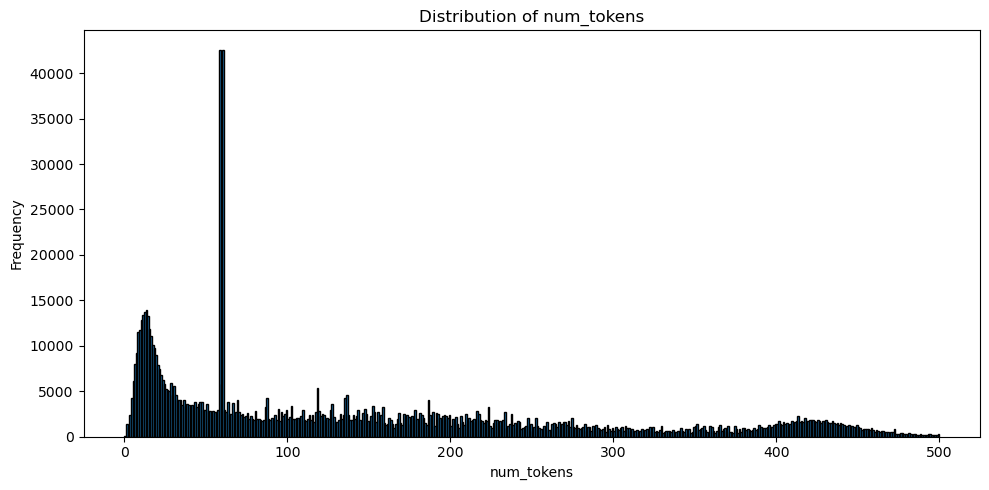

Proportion of short examples (num_tokens <= 500): 94.3042%


In [21]:
import matplotlib.pyplot as plt

sorted_num_tokens = sorted(num_tokens)
plt.figure(figsize=(10, 5))
plt.hist(sorted_num_tokens, bins=500, edgecolor="black")
plt.title("Distribution of num_tokens")
plt.xlabel("num_tokens")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(f"Proportion of short examples (num_tokens <= 500): {len(short_ids) / num_lines:.4%}")

### Inspect long messages

Print and inspect 10 random long_id messages from the dataset.

In [17]:
import random

# Pick 10 random IDs from long_ids
sample_size = min(10, len(long_ids))
sampled_long_ids = random.sample(long_ids, sample_size)
sampled_long_ids_set = set(sampled_long_ids)

print(f"Sampled long row IDs: {sorted(sampled_long_ids)}\n")

# Iterate through streaming dataset and print selected rows
found = 0
for i, row in enumerate(ds):
    if i in sampled_long_ids_set:
        print("=" * 100)
        print(f"Row index: {i} | domain: {row.get('domain')} | num_turns: {len(row.get('messages', []))}")
        print("-" * 100)
        for turn_idx, turn in enumerate(row.get("messages", [])):
            print(f"[{turn_idx}] {turn.get('role')}:")
            print(turn.get("content"))
            print()
        found += 1
        if found == sample_size:
            break

Sampled long row IDs: [109089, 171964, 228101, 241559, 337884, 419572, 500863, 662807, 860248, 869969]

Row index: 109089 | domain: Other | num_turns: 2
----------------------------------------------------------------------------------------------------
[0] user:
Here is a review left by a customer on a product. Would you say he was satisfied or dissatisfied? Title: Coming to America Review: Of a good technical visual quality, this DVD presents a hilarious story of setting in California, the USA, where for murky reason residing (to follow a daughter on a student visa, or?) Vlad of Russia, speaking near-perfect English, miraculously befriended Joska from Hungarian origin and tries to meet elementary ties while enjoying relaxed existence in immigrant environment of Los Angeles.A comedy lacking of any sense and ending presents clichés of different ethnic groups mixing into a multicultural pot the USA are.Easy viewing if too superficial recollecting of realistic problems exist.
satisfied
H